In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

### EDA

In [61]:
df = pd.read_csv("data/car_fuel_efficiency_2026.csv")
df = df.loc[:,['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


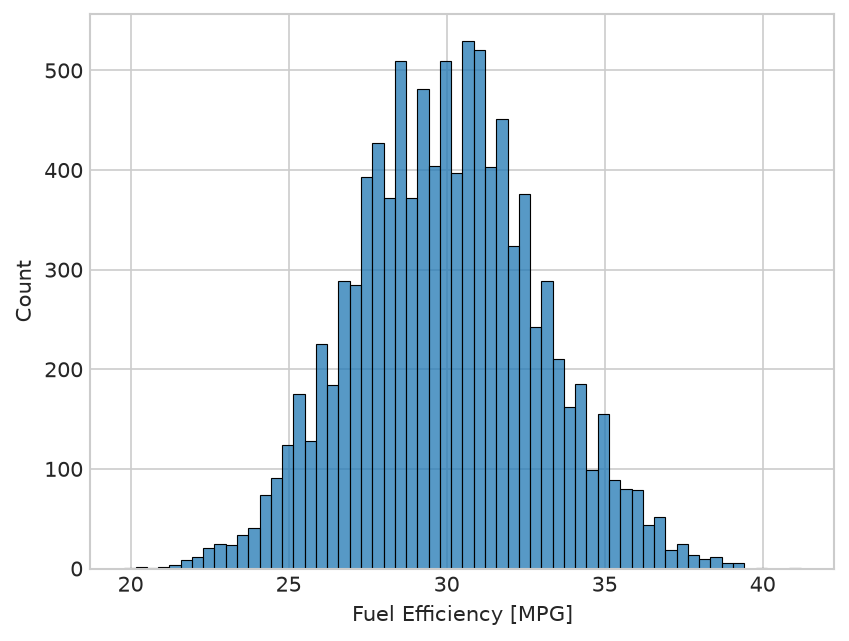

In [62]:
fig = plt.figure(dpi=150)
ax  = fig.add_subplot()
ax  = sns.histplot(data=df, x='fuel_efficiency_mpg', ax=ax)
_   = ax.set_xlabel("Fuel Efficiency [MPG]")

### Q1

In [63]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Q2

In [64]:
df['horsepower'].median()

np.float64(254.0)

In [65]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [66]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

### Q3

In [67]:
df_train_zero = df_train.copy()
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
X_train_zero = df_train_zero.values[:,:-1]
y_train_zero = df_train_zero.values[:,-1]
w0_zero, w_zero = train_linear_regression_reg(X_train_zero, y_train_zero, 0)

mean_val = df_train['horsepower'].mean()
df_train_mean = df_train.copy()
df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_val)
X_train_mean = df_train_mean.values[:,:-1]
y_train_mean = df_train_mean.values[:,-1]
w0_mean, w_mean = train_linear_regression_reg(X_train_mean, y_train_mean, 0)

In [68]:
df_val_zero = df_val.copy()
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)
X_val_zero = df_val_zero.values[:,:-1]
y_val_zero = df_val_zero.values[:,-1]
rmse_zero = np.round(rmse(y_val_zero, w0_zero + X_val_zero @ w_zero),3)

In [69]:
df_val_mean = df_val.copy()
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_val)
X_val_mean = df_val_mean.values[:,:-1]
y_val_mean = df_val_mean.values[:,-1]
rmse_mean = np.round(rmse(y_val_mean, w0_mean + X_val_mean @ w_mean),3)

In [70]:
print(f"RMSE for fill with Zero: {rmse_zero}")
print(f"RMSE for fill with Mean: {rmse_mean}")

RMSE for fill with Zero: 2.205
RMSE for fill with Mean: 2.202


### Q4

In [73]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0_zero, w_zero = train_linear_regression_reg(X_train_zero, y_train_zero, r)
    rmse_zero = np.round(rmse(y_val_zero, w0_zero + X_val_zero @ w_zero),4)
    print(f"RMSE for r = {r}: {rmse_zero}")

RMSE for r = 0: 2.2053
RMSE for r = 0.01: 2.2058
RMSE for r = 0.1: 2.2241
RMSE for r = 1: 2.3492
RMSE for r = 5: 2.4094
RMSE for r = 10: 2.4195
RMSE for r = 100: 2.4292


### Q5

In [77]:
rmse_scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train_zero = df_train.copy()
    df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
    X_train_zero = df_train_zero.values[:,:-1]
    y_train_zero = df_train_zero.values[:,-1]
    w0_zero, w_zero = train_linear_regression_reg(X_train_zero, y_train_zero, 0)

    df_val_zero = df_val.copy()
    df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)
    X_val_zero = df_val_zero.values[:,:-1]
    y_val_zero = df_val_zero.values[:,-1]
    rmse_zero = rmse(y_val_zero, w0_zero + X_val_zero @ w_zero)

    rmse_scores.append(rmse_zero)

print(f"Standard Deviation is: {np.round(np.std(rmse_scores),3)}")

Standard Deviation is: 0.029


### Q6

In [86]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_combined = pd.concat([df_train.copy(),df_val.copy()])
df_combined['horsepower'] = df_combined['horsepower'].fillna(0)
X_combined = df_combined.values[:,:-1]
y_combined = df_combined.values[:,-1]
w0_combined, w_combined = train_linear_regression_reg(X_combined, y_combined, 0.001)

df_test = df_test.copy()
df_test['horsepower'] = df_test['horsepower'].fillna(0)
X_test = df_test.values[:,:-1]
y_test = df_test.values[:,-1]
rmse_combined = rmse(y_test, w0_combined + X_test @ w_combined)

print(f"RMSE: {np.round(rmse_combined,3)}")

RMSE: 2.236
